# Fig 3c — Aggregation strategy comparison (MIL vs Vote vs Avg)

For each foundation model, compare patient-level aggregation strategies on the **7 shared classification tasks** (5-fold CV, Random Forest head).

**Question:** which aggregation strategy works best for which model?

## Recommended views (implemented below)

| View | Purpose |
|------|---------|
| **Summary table** | Mean AUPRC per model × strategy; best strategy and margin vs runner-up |
| **Grouped bar chart** | Quick global comparison — three bars per model, grouped & ordered like Fig3_a |
| **Heatmap (model × strategy)** | Compact overview; color = mean AUPRC across tasks |
| **Task win-rate bars** | Per model, share of tasks where each strategy ranks first (ties split) |
| **Task-level dot plot** | See *where* a strategy wins or loses (task × strategy, one panel per model) |

Data source: `scFM_eval/results/classification.metrics.csv`  
Model order matches **Fig3_a_v8**: groups `Baseline → Geneformer → Other → scGPT`, models ranked by macro mean AUPRC (MIL) within each group.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon

REPO_ROOT = Path('../../').resolve()
METRICS_PATH = REPO_ROOT / 'results' / 'classification.metrics.csv'
PLOTS_DIR = Path('./plots')
RESULTS_DIR = Path('./results/aggregation_strategy')
PLOTS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

STRATEGIES = ['MIL', 'vote', 'avg']
STRATEGY_LABELS = {'MIL': 'MIL', 'vote': 'Vote', 'avg': 'Avg'}
STRATEGY_COLORS = {'MIL': '#4C72B0', 'vote': '#DD8452', 'avg': '#55A868'}
CLASSIFIER = 'randomforest'
METRIC = 'AUPRC'
SORT_STRATEGY = 'MIL'  # Fig3_a uses the active strategy's macro mean for within-group ordering


def process_and_sort(task_df: pd.DataFrame, sort_strategy: str = SORT_STRATEGY):
    """Match Fig3_a_v8: sort by group (asc), then macro mean AUPRC within group (desc)."""
    model_means = (
        task_df[task_df['strategy'] == sort_strategy]
        .groupby('model_display', as_index=False)
        .agg(mean_overall=('mean_auprc', 'mean'))
    )
    model_groups = task_df[['model_display', 'group']].drop_duplicates()
    sorted_models = model_means.merge(model_groups, on='model_display')
    sorted_models = sorted_models.rename(columns={'model_display': 'experiment'})
    sorted_models = sorted_models.sort_values(by=['group', 'mean_overall'], ascending=[True, False])
    model_order = sorted_models['experiment'].tolist()
    return sorted_models, model_order


def build_group_color_map(sorted_models: pd.DataFrame) -> dict[str, tuple]:
    groups = sorted_models['group'].unique().tolist()
    palette = sns.color_palette('husl', len(groups))
    return dict(zip(groups, palette))


def add_group_x_dividers(ax, sorted_models: pd.DataFrame, *, n_hue: int = 1):
    """Vertical dividers and colored tick labels between model groups."""
    counts = sorted_models.groupby('group', sort=False).size().tolist()
    pos = 0
    for count in counts[:-1]:
        pos += count
        ax.axvline(pos * n_hue - 0.5, color='gray', linewidth=0.8, alpha=0.45)


def style_model_tick_labels(ax, sorted_models: pd.DataFrame, color_map: dict[str, tuple], axis: str = 'x'):
    group_by_model = sorted_models.set_index('experiment')['group']
    ticks = ax.get_xticklabels() if axis == 'x' else ax.get_yticklabels()
    for tick in ticks:
        tick.set_color(color_map[group_by_model[tick.get_text()]])


def add_group_row_dividers(ax, sorted_models: pd.DataFrame):
    counts = sorted_models.groupby('group', sort=False).size().tolist()
    pos = 0
    for count in counts[:-1]:
        pos += count
        ax.axhline(pos - 0.5, color='gray', linewidth=0.8, alpha=0.45)

In [23]:
metrics = pd.read_csv(METRICS_PATH)
df = metrics[
    (metrics['classifier'] == CLASSIFIER)
    & (metrics['strategy'].isin(STRATEGIES))
].copy()

# Match Fig3_a_v8 exclusions
exclude = (
    df.model_display.str.contains('continue', case=False, na=False)
    | df.model_display.str.contains('Full', case=False, na=False)
    | df.model_display.isin(['PCA [100]', 'PCA [50]'])
)
df = df[~exclude].copy()

missing = df.groupby(['model_display', 'exp_display', 'strategy']).size().unstack('strategy')
incomplete = missing[missing.isna().any(axis=1)]
if len(incomplete):
    display(incomplete.head())
    raise ValueError(f'{len(incomplete)} model×task pairs missing a strategy')

print(f'{df["model_display"].nunique()} models, {df["exp_display"].nunique()} tasks, {len(df)} fold rows')
df.head()

15 models, 7 tasks, 1530 fold rows


,AUC,AUPRC,Accuracy,F1,Precision,Recall,model,exp,exp_path,strategy,classifier,metrics_path,group,model_display,exp_display
0,0.571429,0.250000,0.875000,0.466667,0.437500,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
1,0.916667,0.833333,0.750000,0.428571,0.375000,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
2,0.833333,0.750000,0.750000,0.428571,0.375000,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
3,0.583333,0.366667,0.750000,0.428571,0.375000,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo
4,0.000000,0.142857,0.857143,0.461538,0.428571,0.5,cellplm_85M-20231027,brca_chemo,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,vote,randomforest,/mnt/data/__output_v7/exp/cellplm/85M-20231027...,Other,CellPLM,Treatment Naive vs Neoadjuvant Chemo


In [24]:
# Task-level mean AUPRC (mean over CV folds), then model-level macro mean over tasks
task_summary = (
    df.groupby(['model_display', 'exp_display', 'strategy', 'group'], as_index=False)
    .agg(mean_auprc=(METRIC, 'mean'), n_folds=(METRIC, 'count'))
)

model_summary = (
    task_summary.groupby(['model_display', 'strategy', 'group'], as_index=False)
    .agg(mean_auprc=('mean_auprc', 'mean'), n_tasks=('exp_display', 'nunique'))
)

sorted_models, model_order = process_and_sort(task_summary, sort_strategy=SORT_STRATEGY)
color_map = build_group_color_map(sorted_models)
group_map = sorted_models.set_index('experiment')['group']

pivot = model_summary.pivot(index='model_display', columns='strategy', values='mean_auprc')
pivot = pivot[STRATEGIES]
pivot['group'] = group_map
pivot = pivot.loc[model_order]

sorted_models.to_csv(RESULTS_DIR / 'model_order_fig3a.csv', index=False)
pivot.to_csv(RESULTS_DIR / 'model_strategy_mean_auprc.csv')
task_summary.to_csv(RESULTS_DIR / 'task_strategy_mean_auprc.csv', index=False)

print('Model order (Fig3_a groups: Baseline → Geneformer → Other → scGPT):')
for group_name, group_df in sorted_models.groupby('group', sort=False):
    print(f'  {group_name}: {group_df["experiment"].tolist()}')
pivot.round(4)

Model order (Fig3_a groups: Baseline → Geneformer → Other → scGPT):
  Baseline: ['scVI', 'PCA [20]', 'HVG']
  Geneformer: ['GF-V2 [cancer]', 'GF-V2', 'GF-V2-Deep', 'GF-V1']
  Other: ['SCimiarity', 'STATE', 'scConcept', 'scFoundation', 'Nicheformer', 'CellPLM']
  scGPT: ['scGPT [cancer]', 'scGPT']


strategy,MIL,vote,avg,group
model_display,,,,
scVI,0.9013,0.9082,0.8664,Baseline
PCA [20],0.8909,0.8553,0.7719,Baseline
HVG,0.8779,0.8806,0.9048,Baseline
GF-V2 [cancer],0.9048,0.8598,0.8800,Geneformer
GF-V2,0.8979,0.8544,0.8547,Geneformer
GF-V2-Deep,0.8641,0.8552,0.8606,Geneformer
GF-V1,0.8519,0.8472,0.8364,Geneformer
SCimiarity,0.9371,0.8691,0.8818,Other
STATE,0.9169,0.8828,0.8693,Other


In [25]:
def best_strategy_row(row: pd.Series) -> pd.Series:
    vals = row[STRATEGIES]
    best = vals.idxmax()
    ranked = vals.sort_values(ascending=False)
    margin = ranked.iloc[0] - ranked.iloc[1]
    return pd.Series({
        'best_strategy': best,
        'best_auprc': ranked.iloc[0],
        'runner_up_strategy': ranked.index[1],
        'runner_up_auprc': ranked.iloc[1],
        'margin_vs_runner_up': margin,
        'MIL_minus_vote': row['MIL'] - row['vote'],
        'MIL_minus_avg': row['MIL'] - row['avg'],
        'vote_minus_avg': row['vote'] - row['avg'],
    })


best_df = pivot.apply(best_strategy_row, axis=1)
best_df['group'] = pivot['group']
best_df = best_df.loc[model_order]  # Fig3_a group order
best_df.to_csv(RESULTS_DIR / 'best_strategy_per_model.csv')

print('Best strategy counts (macro mean over tasks):')
display(best_df['best_strategy'].value_counts().rename('n_models'))
best_df.round(4)

Best strategy counts (macro mean over tasks):


best_strategy
MIL     11
vote     2
avg      2
Name: n_models, dtype: int64

,best_strategy,best_auprc,runner_up_strategy,runner_up_auprc,margin_vs_runner_up,MIL_minus_vote,MIL_minus_avg,vote_minus_avg,group
model_display,,,,,,,,,
scVI,vote,0.9082,MIL,0.9013,0.0069,-0.0069,0.0350,0.0418,Baseline
PCA [20],MIL,0.8909,vote,0.8553,0.0356,0.0356,0.1189,0.0833,Baseline
HVG,avg,0.9048,vote,0.8806,0.0243,-0.0026,-0.0269,-0.0243,Baseline
GF-V2 [cancer],MIL,0.9048,avg,0.8800,0.0248,0.0450,0.0248,-0.0203,Geneformer
GF-V2,MIL,0.8979,avg,0.8547,0.0431,0.0435,0.0431,-0.0004,Geneformer
GF-V2-Deep,MIL,0.8641,avg,0.8606,0.0035,0.0089,0.0035,-0.0055,Geneformer
GF-V1,MIL,0.8519,vote,0.8472,0.0047,0.0047,0.0155,0.0107,Geneformer
SCimiarity,MIL,0.9371,avg,0.8818,0.0552,0.0679,0.0552,-0.0127,Other
STATE,MIL,0.9169,vote,0.8828,0.0342,0.0342,0.0477,0.0135,Other


In [26]:
# Task-level wins: for each model×task, which strategy has highest mean AUPRC?
task_pivot = task_summary.pivot_table(
    index=['model_display', 'exp_display'],
    columns='strategy',
    values='mean_auprc',
)
task_pivot = task_pivot[STRATEGIES]

def task_winners(row: pd.Series) -> str:
    mx = row.max()
    winners = row[row == mx].index.tolist()
    return '/'.join(winners)

task_pivot['winner'] = task_pivot.apply(task_winners, axis=1)
task_pivot['best_strategy'] = task_pivot[STRATEGIES].idxmax(axis=1)

win_counts = (
    task_pivot.reset_index()
    .groupby(['model_display', 'best_strategy'])
    .size()
    .unstack('best_strategy', fill_value=0)
    .reindex(columns=STRATEGIES, fill_value=0)
)
win_counts['n_tasks'] = win_counts.sum(axis=1)
win_counts['group'] = group_map
win_counts = win_counts.loc[model_order]
win_counts.to_csv(RESULTS_DIR / 'task_win_counts_per_model.csv')
win_counts

best_strategy,MIL,vote,avg,n_tasks,group
model_display,,,,,
scVI,5,2,0,7,Baseline
PCA [20],5,2,0,7,Baseline
HVG,4,0,3,7,Baseline
GF-V2 [cancer],4,2,1,7,Geneformer
GF-V2,6,1,0,7,Geneformer
GF-V2-Deep,5,1,1,7,Geneformer
GF-V1,3,2,2,7,Geneformer
SCimiarity,4,2,1,7,Other
STATE,6,1,0,7,Other


In [27]:
# Paired tests: per model, Wilcoxon signed-rank on task-level AUPRC (MIL vs vote, MIL vs avg)
def paired_wilcoxon(model: str, a: str, b: str) -> dict:
    sub = task_pivot.loc[model, [a, b]].dropna()
    if len(sub) < 3:
        return {'model_display': model, 'comparison': f'{a}_vs_{b}', 'n_tasks': len(sub), 'p_value': np.nan}
    try:
        stat, p = wilcoxon(sub[a], sub[b])
    except ValueError:
        stat, p = np.nan, np.nan
    return {
        'model_display': model,
        'comparison': f'{a}_vs_{b}',
        'n_tasks': len(sub),
        'mean_diff': (sub[a] - sub[b]).mean(),
        'wilcoxon_statistic': stat,
        'p_value': p,
    }

stats_rows = []
for model in pivot.index:
    stats_rows.append(paired_wilcoxon(model, 'MIL', 'vote'))
    stats_rows.append(paired_wilcoxon(model, 'MIL', 'avg'))
stats_df = pd.DataFrame(stats_rows)
stats_df['group'] = stats_df['model_display'].map(group_map)
stats_df.to_csv(RESULTS_DIR / 'paired_wilcoxon_mil_vs_others.csv', index=False)
stats_df.round(4)

,model_display,comparison,n_tasks,mean_diff,wilcoxon_statistic,p_value,group
0,scVI,MIL_vs_vote,7,-0.0069,3.0,0.6250,Baseline
1,scVI,MIL_vs_avg,7,0.0350,6.0,0.4375,Baseline
2,PCA [20],MIL_vs_vote,7,0.0356,5.0,0.6250,Baseline
3,PCA [20],MIL_vs_avg,7,0.1189,0.0,0.0156,Baseline
4,HVG,MIL_vs_vote,7,-0.0026,4.0,0.8750,Baseline
5,HVG,MIL_vs_avg,7,-0.0269,4.0,0.4375,Baseline
6,GF-V2 [cancer],MIL_vs_vote,7,0.0450,3.0,0.3125,Geneformer
7,GF-V2 [cancer],MIL_vs_avg,7,0.0248,5.0,0.6250,Geneformer
8,GF-V2,MIL_vs_vote,7,0.0435,4.0,0.2188,Geneformer
9,GF-V2,MIL_vs_avg,7,0.0431,0.0,0.0625,Geneformer


## 1. Grouped bar chart — mean AUPRC per model × strategy

/tmp/ipykernel_35931/1951193137.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


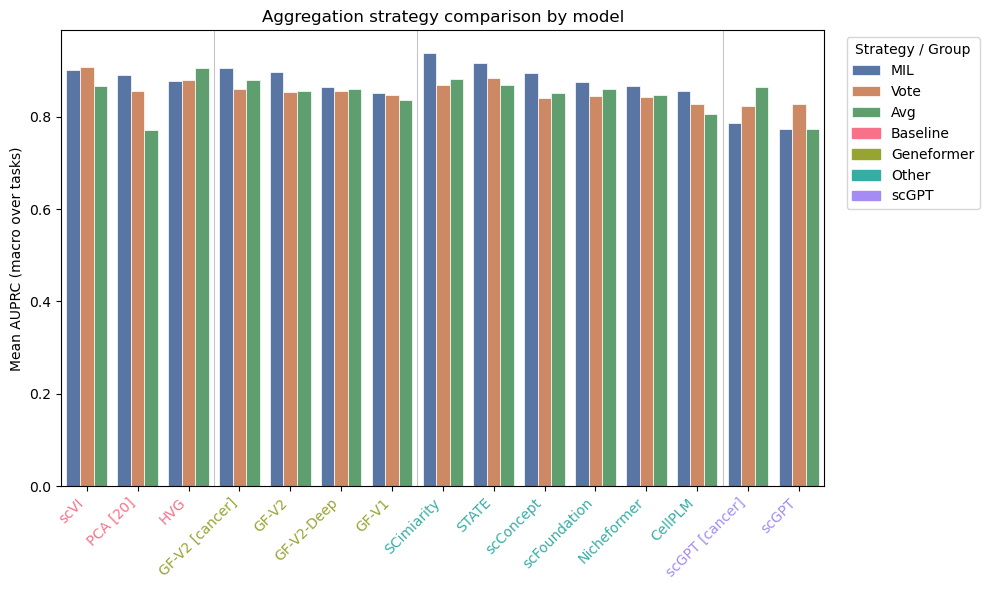

Saved plots/aggregation_strategy_grouped_bars.png


In [28]:
plot_df = model_summary.copy()
plot_df['strategy_label'] = plot_df['strategy'].map(STRATEGY_LABELS)
plot_df['model_display'] = pd.Categorical(plot_df['model_display'], categories=model_order, ordered=True)

fig, ax = plt.subplots(figsize=(max(10, len(model_order) * 0.55), 6))
sns.barplot(
    data=plot_df,
    x='model_display',
    y='mean_auprc',
    hue='strategy_label',
    hue_order=[STRATEGY_LABELS[s] for s in STRATEGIES],
    order=model_order,
    palette=[STRATEGY_COLORS[s] for s in STRATEGIES],
    ax=ax,
    edgecolor='white',
    linewidth=0.5,
)
add_group_x_dividers(ax, sorted_models)
style_model_tick_labels(ax, sorted_models, color_map, axis='x')
ax.set_xlabel('')
ax.set_ylabel('Mean AUPRC (macro over tasks)')
ax.set_title('Aggregation strategy comparison by model')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_ylim(0, min(1.02, plot_df['mean_auprc'].max() + 0.05))
group_patches = [mpatches.Patch(color=c, label=g) for g, c in color_map.items()]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + group_patches, labels=labels + list(color_map.keys()),
          title='Strategy / Group', bbox_to_anchor=(1.02, 1), loc='upper left')


plt.tight_layout()
out = PLOTS_DIR / 'aggregation_strategy_grouped_bars.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## 2. Heatmap — model × strategy mean AUPRC

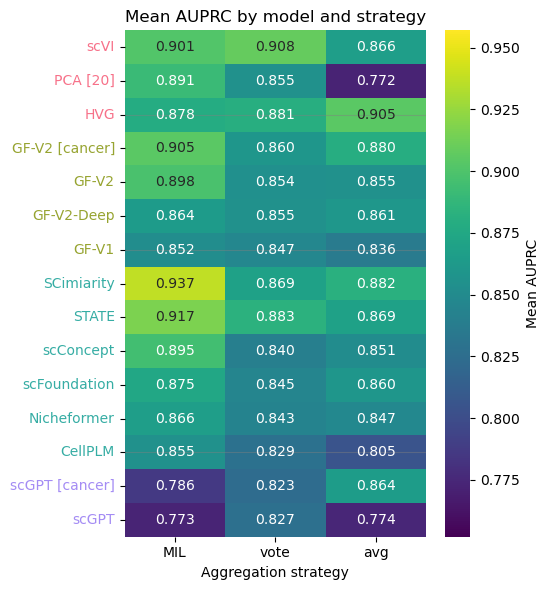

Saved plots/aggregation_strategy_heatmap.png


In [29]:
heat = pivot[STRATEGIES].copy()

fig, ax = plt.subplots(figsize=(5.5, max(6, len(heat) * 0.35)))
sns.heatmap(
    heat,
    annot=heat.round(3),
    fmt='.3f',
    cmap='viridis',
    vmin=heat.values.min() - 0.02,
    vmax=heat.values.max() + 0.02,
    cbar_kws={'label': 'Mean AUPRC'},
    ax=ax,
)
add_group_row_dividers(ax, sorted_models)
style_model_tick_labels(ax, sorted_models, color_map, axis='y')
ax.set_xlabel('Aggregation strategy')
ax.set_ylabel('')
ax.set_title('Mean AUPRC by model and strategy')
plt.tight_layout()
out = PLOTS_DIR / 'aggregation_strategy_heatmap.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## 3. Task win-rate — fraction of tasks where each strategy ranks first

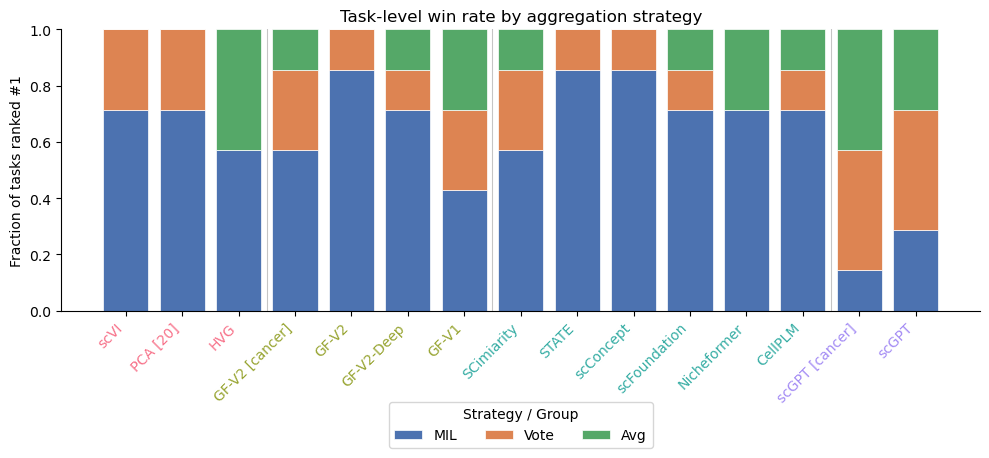

Saved plots/aggregation_strategy_task_win_rate.png


In [30]:
win_frac = win_counts[STRATEGIES].div(win_counts['n_tasks'], axis=0)
win_frac = win_frac.loc[model_order]

fig, ax = plt.subplots(figsize=(max(10, len(model_order) * 0.55), 5))
bottom = np.zeros(len(win_frac))
x = np.arange(len(win_frac))
for strat in STRATEGIES:
    vals = win_frac[strat].values
    ax.bar(
        x,
        vals,
        bottom=bottom,
        label=STRATEGY_LABELS[strat],
        color=STRATEGY_COLORS[strat],
        edgecolor='white',
        linewidth=0.5,
    )
    bottom += vals
add_group_x_dividers(ax, sorted_models)
ax.set_xticks(x)
ax.set_xticklabels(win_frac.index, rotation=45, ha='right')
style_model_tick_labels(ax, sorted_models, color_map, axis='x')
ax.set_ylabel('Fraction of tasks ranked #1')
ax.set_ylim(0, 1)
ax.set_title('Task-level win rate by aggregation strategy')
# group_patches = [mpatches.Patch(color=c, label=g) for g, c in color_map.items()]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles , labels=labels ,
          title='Strategy / Group', bbox_to_anchor=(0.5, -0.3),ncol=3 ,loc='upper center')
# plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.tight_layout()
out = PLOTS_DIR / 'aggregation_strategy_task_win_rate.png'
# plt.axis('off') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

In [31]:
# Task win-rate table (counts + fractions) for reporting / figure caption
win_rate_table = win_counts[['group', 'n_tasks'] + STRATEGIES].copy()
for strat in STRATEGIES:
    win_rate_table[f'{strat}_win_rate'] = win_counts[strat] / win_counts['n_tasks']

win_rate_table['MIL_wins'] = win_counts['MIL']
win_rate_table['vote_wins'] = win_counts['vote']
win_rate_table['avg_wins'] = win_counts['avg']

# Primary display columns: model, group, per-strategy wins and win rates
display_cols = [
    'group', 'n_tasks',
    'MIL_wins', 'MIL_win_rate',
    'vote_wins', 'vote_win_rate',
    'avg_wins', 'avg_win_rate',
]
win_rate_display = win_rate_table[display_cols].copy()
win_rate_display.index.name = 'model_display'

# Pooled summary across all model×task comparisons
pooled = {
    'group': 'All models',
    'n_tasks': int(win_counts['n_tasks'].sum()),
    'MIL_wins': int(win_counts['MIL'].sum()),
    'vote_wins': int(win_counts['vote'].sum()),
    'avg_wins': int(win_counts['avg'].sum()),
}
for strat in STRATEGIES:
    pooled[f'{strat}_win_rate'] = pooled[f'{strat}_wins'] / pooled['n_tasks']
pooled_row = pd.DataFrame([pooled], index=['All models'])
win_rate_display = pd.concat([win_rate_display, pooled_row])

out_csv = RESULTS_DIR / 'task_win_rate_per_model.csv'
win_rate_display.round({'MIL_win_rate': 3, 'vote_win_rate': 3, 'avg_win_rate': 3}).to_csv(out_csv)
print(f'Saved {out_csv}')

win_rate_display.round({'MIL_win_rate': 3, 'vote_win_rate': 3, 'avg_win_rate': 3})

Saved results/aggregation_strategy/task_win_rate_per_model.csv


,group,n_tasks,MIL_wins,MIL_win_rate,vote_wins,vote_win_rate,avg_wins,avg_win_rate
scVI,Baseline,7,5,0.714,2,0.286,0,0.000
PCA [20],Baseline,7,5,0.714,2,0.286,0,0.000
HVG,Baseline,7,4,0.571,0,0.000,3,0.429
GF-V2 [cancer],Geneformer,7,4,0.571,2,0.286,1,0.143
GF-V2,Geneformer,7,6,0.857,1,0.143,0,0.000
GF-V2-Deep,Geneformer,7,5,0.714,1,0.143,1,0.143
GF-V1,Geneformer,7,3,0.429,2,0.286,2,0.286
SCimiarity,Other,7,4,0.571,2,0.286,1,0.143
STATE,Other,7,6,0.857,1,0.143,0,0.000
scConcept,Other,7,6,0.857,1,0.143,0,0.000


## 4. Task-level dot plot — strategy curves per model

/tmp/ipykernel_35931/3071418680.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')
/tmp/ipykernel_35931/3071418680.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')
/tmp/ipykernel_35931/3071418680.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')
/tmp/ipykernel_35931/3071418680.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha='right')


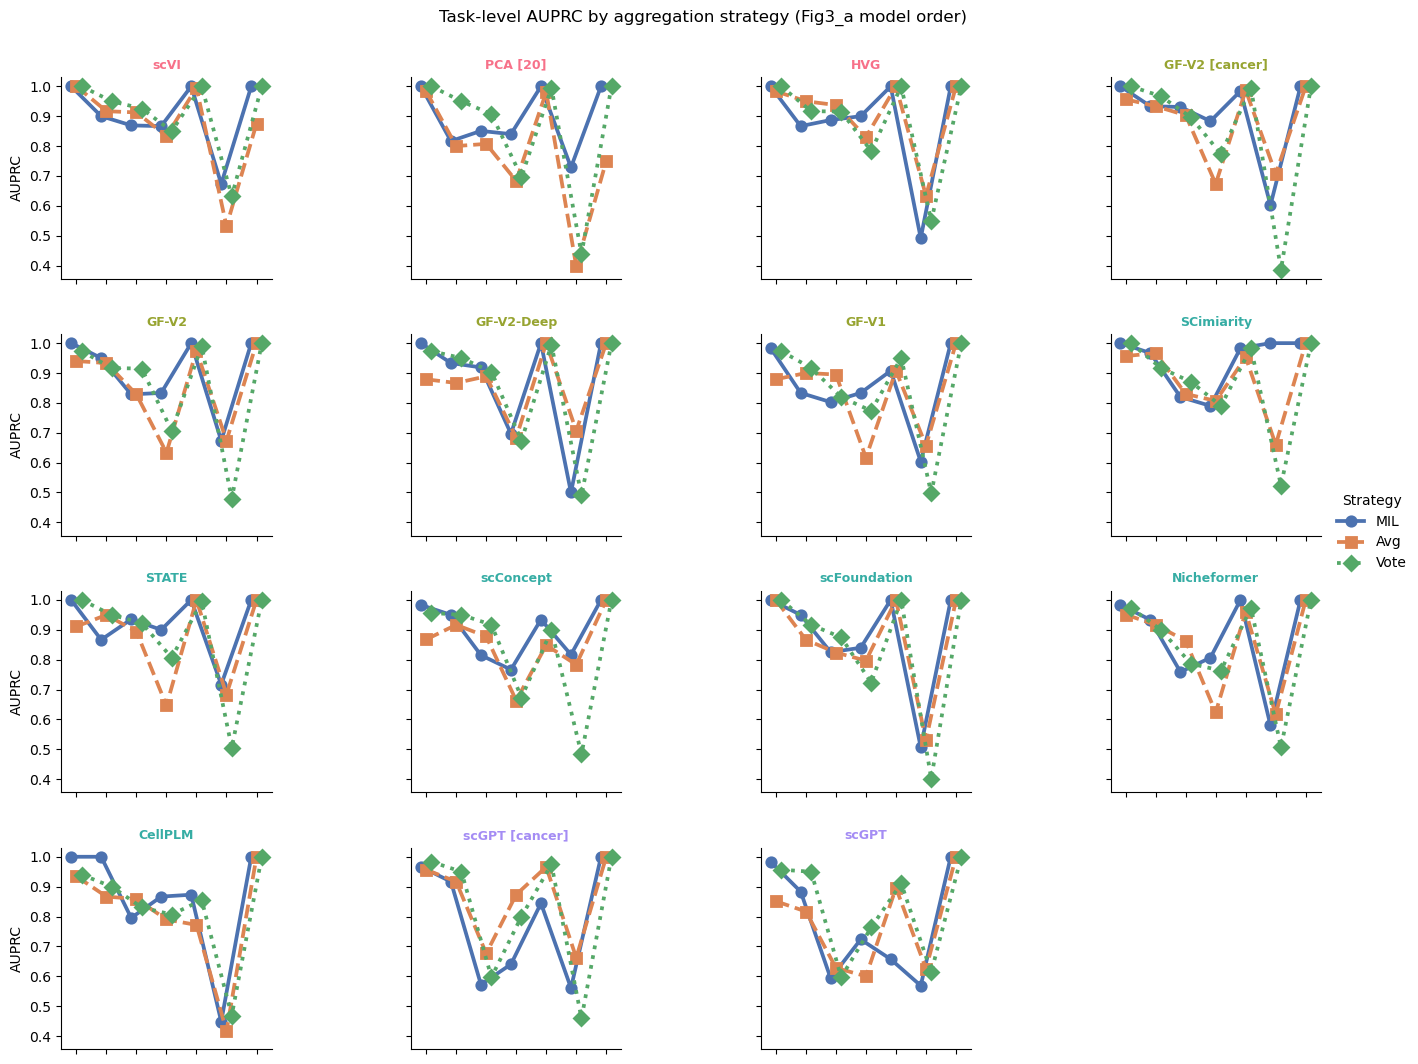

Saved plots/aggregation_strategy_task_facets.png


In [32]:
task_long = task_summary.copy()
task_long['strategy_label'] = task_long['strategy'].map(STRATEGY_LABELS)
task_order = sorted(task_long['exp_display'].unique())

g = sns.FacetGrid(
    task_long,
    col='model_display',
    col_wrap=4,
    height=2.8,
    aspect=1.2,
    sharey=True,
    sharex=True,
    col_order=model_order,
)
g.map_dataframe(
    sns.pointplot,
    x='exp_display',
    y='mean_auprc',
    hue='strategy_label',
    order=task_order,
    palette=[STRATEGY_COLORS[s] for s in STRATEGIES],
    dodge=0.35,
    markers=['o', 's', 'D'],
    linestyles=['-', '--', ':'],
    errorbar=None,
)
for ax, model in zip(g.axes.flat, model_order):
    ax.set_title(model, color=color_map[group_map[model]], size=9, fontweight='bold')
g.set_axis_labels('', 'AUPRC')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=60, labelsize=6)
    ax.set_xticklabels(ax.get_xticklabels(), ha='right')
g.add_legend(title='Strategy')
g.fig.subplots_adjust(top=0.92)
g.fig.suptitle('Task-level AUPRC by aggregation strategy (Fig3_a model order)', y=0.98)
out = PLOTS_DIR / 'aggregation_strategy_task_facets.png'
g.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## 5. Delta heatmap — MIL minus Vote / Avg (task-macro mean)

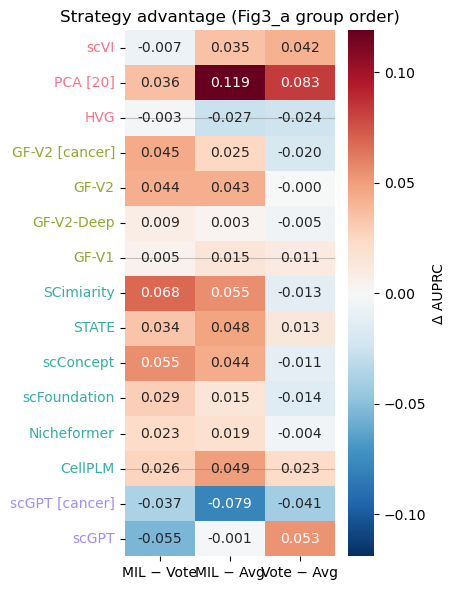

Saved plots/aggregation_strategy_deltas.png


In [33]:
delta = pd.DataFrame({
    'MIL − Vote': pivot['MIL'] - pivot['vote'],
    'MIL − Avg': pivot['MIL'] - pivot['avg'],
    'Vote − Avg': pivot['vote'] - pivot['avg'],
})
delta.to_csv(RESULTS_DIR / 'strategy_deltas.csv')

v = np.nanmax(np.abs(delta.values))
fig, ax = plt.subplots(figsize=(4.5, max(6, len(delta) * 0.35)))
sns.heatmap(
    delta,
    annot=delta.round(3),
    fmt='.3f',
    cmap='RdBu_r',
    center=0,
    vmin=-v,
    vmax=v,
    cbar_kws={'label': 'Δ AUPRC'},
    ax=ax,
)
add_group_row_dividers(ax, sorted_models)
style_model_tick_labels(ax, sorted_models, color_map, axis='y')
ax.set_ylabel('')
ax.set_title('Strategy advantage (Fig3_a group order)')
plt.tight_layout()
out = PLOTS_DIR / 'aggregation_strategy_deltas.png'
fig.savefig(out, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved {out}')

## Summary

Key outputs written to `./results/aggregation_strategy/` and `./plots/`:

- `best_strategy_per_model.csv` — direct answer to *which strategy for which model*
- `task_win_counts_per_model.csv` — task-level win counts per model
- `task_win_rate_per_model.csv` — task win-rate table (counts + fractions) for figures/captions
- `paired_wilcoxon_mil_vs_others.csv` — whether MIL vs alternatives differs significantly per model

**Interpretation tips:**
- Use the **macro mean table** for an overall ranking; use **task win-rate** when a model is close on average but wins different tasks.
- Large positive **MIL − Vote** on embedding-heavy models often indicates MIL learns patient-level patterns vote misses; **Vote/Avg** wins on baselines (HVG, scVI) where cell-level signal is already well separated.